In [34]:
import geopandas as gpd
import pandas as pd
import numpy as np
# from numpy import infinity
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib .patches import Patch, Rectangle
from matplotlib.lines import Line2D
from shapely.geometry import Point
from shapely.geometry import LineString

commute21 = pd.read_csv(r"../data/sodb_2021_dochadzka_denne_lm_rk.csv", encoding="windows-1250")
commute11 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2011.csv", sep=";")
commute01 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2001.csv", sep=";")

obce = gpd.read_file(r"../data/liptov_obce.csv", encoding = "windows-1250")
map2 = gpd.read_file(r"../data/geo/liptov.shp")
okresy = gpd.read_file(r"../data/geo/liptov_okresy.shp")
lipt_colors = pd.read_csv(r"../data/colors.csv", sep=";")
map2.drop(columns = ["DOW", "FACC", "IDN3", "NM3", "IDN2", "NM2", "NUTS1", "NUTS1_CODE", "NUTS2", "NUTS2_CODE", "NUTS3", "NUTS3_CODE", "LAU1", "LAU1_CODE", "LAU2", "LAU2_CODE", "VYMERA", "Shape_Area", "Shape_Leng"], inplace = True)
commute11 = (commute11).rename(columns = {"obecA": "obecA", "obecB": "obecB", "POCET": "pocet11"})
commute01 = (commute01).rename(columns = {"Obec trvaleho pobytu": "obecA", "Miesto pracoviska (obec)": "obecB", "POCET": "pocet01"})

commute21[["obecA", "obecB"]] = commute21[["obecA", "obecB"]].astype(str)
commute21["pocet"] = commute21["pocet"].astype(int)
commute11[["obecA", "obecB"]] = commute11[["obecA", "obecB"]].astype(str)
commute11["pocet11"] = commute11["pocet11"].astype(int)
commute01[["obecA", "obecB"]] = commute01[["obecA", "obecB"]].astype(str)
commute01["pocet01"] = commute01["pocet01"].astype(int)


lipt_colors["obec_id"] = lipt_colors["obec_id"].astype(str)
map2["IDN4"] = map2["IDN4"].astype(str)
obce["kod"] = obce["kod"].astype(str)

unique_obce = map2["IDN4"].apply(str).tolist()

commute11 = commute11[commute11["Periodicita dochadzky"] == 1]
commute11 = commute11[commute11["obecA"].isin(unique_obce) & commute11["obecB"].isin(unique_obce)]
commute01 = commute01[commute01["Periodicita dochadzky"] == 1]
commute01 = commute01[commute01["obecA"].isin(unique_obce) & commute01["obecB"].isin(unique_obce)]

obce_gdf = gpd.GeoDataFrame(
    obce,
    geometry=[Point(xy) for xy in zip(obce["x"], obce["y"])],
    crs="EPSG:5514"
)
print(obce.columns)

Index(['code', 'nazov', 'kod_obce', 'typ', 'okMesto', 'kMesto', 'IDN3', 'NM3',
       'IDN2', 'NM2', 'NAZOVOBCE', 'KODOBCE', 'nazov_1', 'kod', 'obyv', 'x',
       'y'],
      dtype='object')


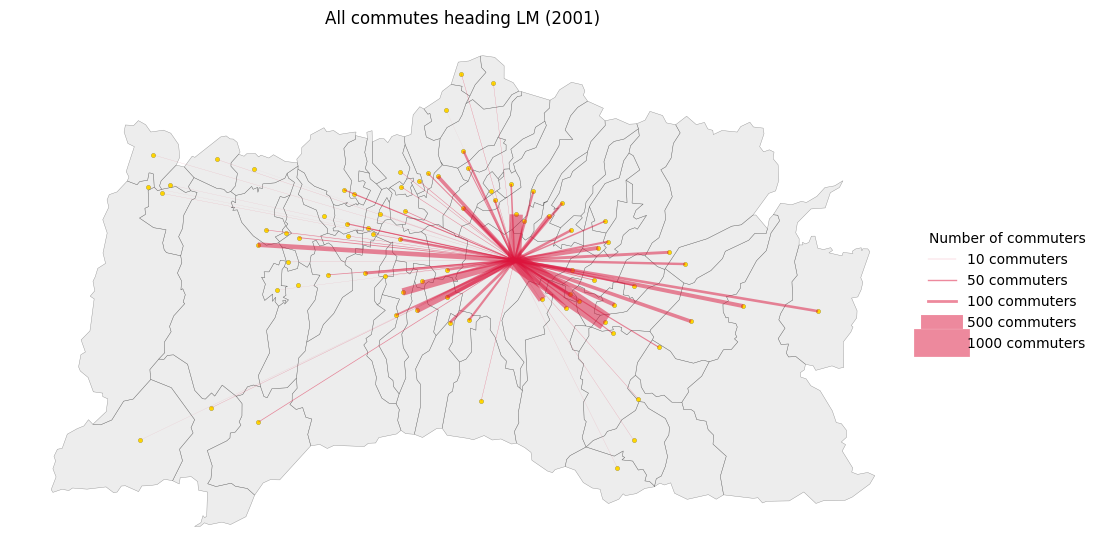

In [35]:
commute01 = commute01.merge(
    map2,
    left_on = "obecA",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecA_nazov"})
commuting01 = commute01.merge(
    map2,
    left_on = "obecB",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecB_nazov"})
# print(commute1.head())

# print(commuting01.head())
commuting01 = commuting01.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecA",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "start_x", "y": "start_y", "kod": "kod_start"})

commuting_01 = commuting01.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecB",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "end_x", "y": "end_y", "kod": "kod_dest"})
commuting01_gdf = gpd.GeoDataFrame(
    commuting_01,
    geometry=[Point(xy) for xy in zip(commuting_01["start_x"], commuting_01["start_y"])],
    crs="EPSG:5514"
)
# print(commuting_gdf.head())

commuting_01["geometry"] = commuting_01.apply(
    lambda row: LineString([(row["start_x"], row["start_y"]), (row["end_x"], row["end_y"])]),
    axis = 1
)
line_gdf = gpd.GeoDataFrame(commuting_01, geometry = "geometry", crs="EPSG:5514")

flow_values = [10, 50, 100, 500, 1000]
scale = 50

flows_510262 = line_gdf[line_gdf["kod_dest"] == "510262"]
# print(flows_510262.sort_values(by = "pocet01", ascending = False))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "crimson",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510262.plot(
    ax = ax,
    linewidth = flows_510262["pocet01"]/50,
    alpha = 0.5,
    color = "crimson",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All commutes heading LM (2001)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/LM_flows_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

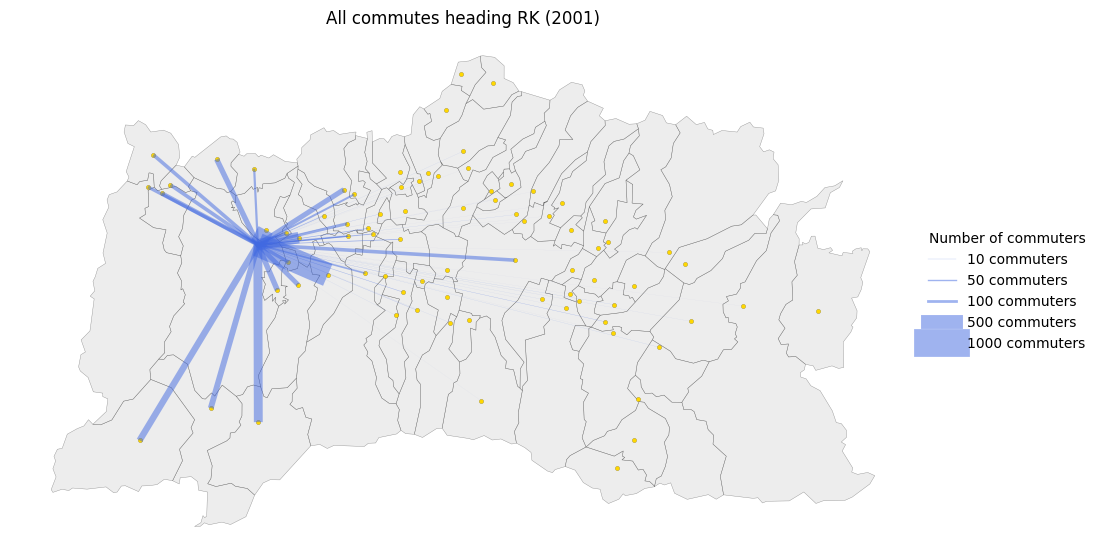

In [36]:
flows_510998 = line_gdf[line_gdf["kod_dest"] == "510998"]
# print(flows_510998.sort_values(by = "pocet01", ascending = False))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "royalblue",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510998.plot(
    ax = ax,
    linewidth = flows_510998["pocet01"]/50,
    alpha = 0.5,
    color = "royalblue",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All commutes heading RK (2001)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/RK_flows_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

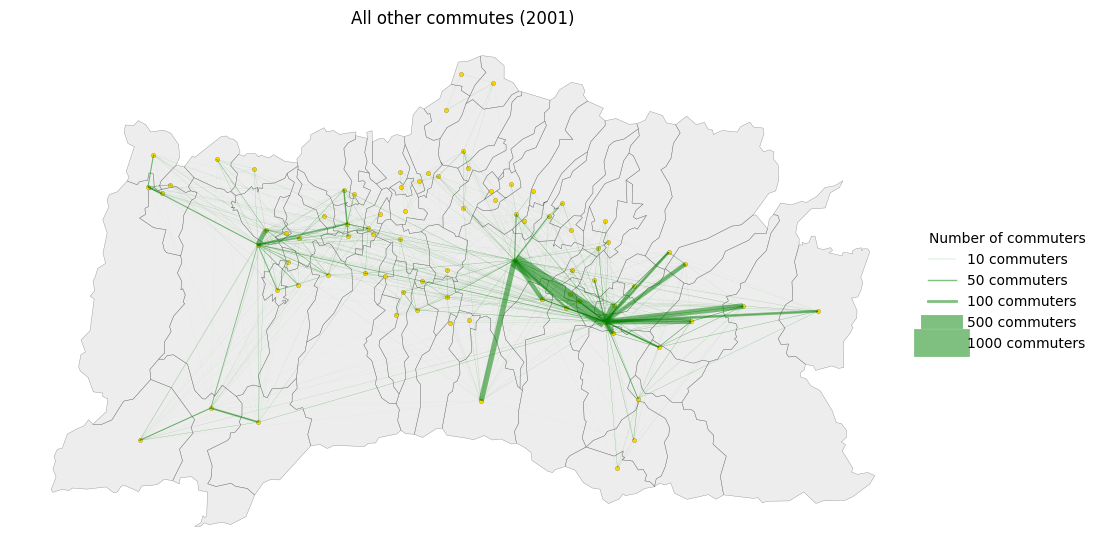

In [37]:
# flows_other = line_gdf[(line_gdf["kod_dest"] != "510262") | (line_gdf["kod_dest"] != "510998")]
flows_other = line_gdf[(~line_gdf["kod_dest"].isin(["510262", "510998"]))]
# print(flows_other.sort_values(by = "pocet01", ascending = False))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "green",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_other.plot(
    ax = ax,
    linewidth = flows_other["pocet01"]/50,
    alpha = 0.5,
    color = "green",
    label = "other flows"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All other commutes (2001)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/other_flows_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

     obecA   obecB  Periodicita dochadzky  pocet11  IDN4_x        obecA_nazov  \
15  510262  510262                      1     6513  510262  Liptovský Mikuláš   
49  510726  510262                      1      465  510726   Liptovský Hrádok   
19  510327  510262                      1      312  510327           Bobrovec   
85  511196  510262                      1      205  511196     Závažná Poruba   
23  510408  510262                      1      175  510408            Dúbrava   
..     ...     ...                    ...      ...     ...                ...   
75  511064  510262                      1        3  511064             Švošov   
74  511056  510262                      1        3  511056         Štiavnička   
14  507407  510262                      1        2  507407              Turík   
78  511102  510262                      1        2  511102     Valaská Dubová   
67  510955  510262                      1        1  510955              Potok   

                           

<Figure size 1169x827 with 0 Axes>

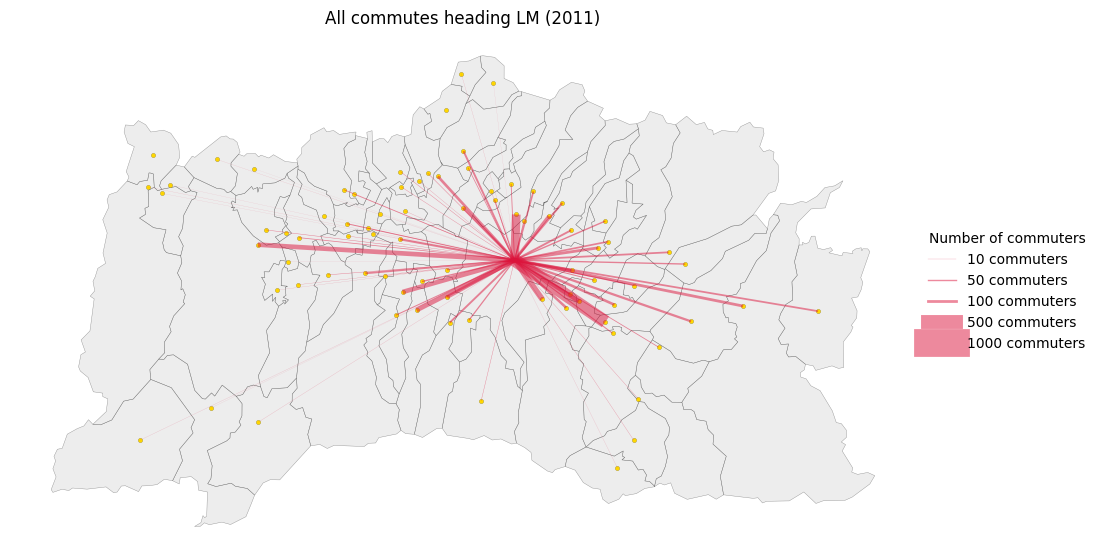

In [38]:
commute11 = commute11.merge(
    map2,
    left_on = "obecA",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecA_nazov"})
commuting11 = commute11.merge(
    map2,
    left_on = "obecB",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecB_nazov"})
# print(commute1.head())

# print(commuting11.head())
commuting11 = commuting11.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecA",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "start_x", "y": "start_y", "kod": "kod_start"})

commuting_11 = commuting11.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecB",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "end_x", "y": "end_y", "kod": "kod_dest"})
commuting11_gdf = gpd.GeoDataFrame(
    commuting_11,
    geometry=[Point(xy) for xy in zip(commuting_11["start_x"], commuting_11["start_y"])],
    crs="EPSG:5514"
)
# print(commuting_gdf.head())

background = gpd.read_file(r"../data/geo/liptov.shp")

commuting_11["geometry"] = commuting_11.apply(
    lambda row: LineString([(row["start_x"], row["start_y"]), (row["end_x"], row["end_y"])]),
    axis = 1
)
line_gdf = gpd.GeoDataFrame(commuting_11, geometry = "geometry", crs="EPSG:5514")

flows_510262 = line_gdf[line_gdf["kod_dest"] == "510262"]
print(flows_510262.sort_values(by = "pocet11", ascending = False))
plt.figure(figsize = (11.69, 8.27))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "crimson",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510262.plot(
    ax = ax,
    linewidth = flows_510262["pocet11"]/50,
    alpha = 0.5,
    color = "crimson",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)


plt.title("All commutes heading LM (2011)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/LM_flows_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

      obecA   obecB  Periodicita dochadzky  pocet11  IDN4_x  \
773  510998  510998                      1     5969  510998   
774  511005  510998                      1      604  511005   
743  510599  510998                      1      450  510599   
759  510785  510998                      1      329  510785   
746  510629  510998                      1      272  510629   
..      ...     ...                    ...      ...     ...   
768  510921  510998                      1        1  510921   
728  510319  510998                      1        1  510319   
788  556807  510998                      1        1  556807   
789  558281  510998                      1        1  558281   
757  510751  510998                      1        1  510751   

           obecA_nazov                                         geometry_x  \
773         Ružomberok  POLYGON Z ((-406385.13 -1186159.31 0, -406079....   
774   Liptovské Sliače  POLYGON Z ((-398286.43 -1190624.9 0, -397965.9...   
743         

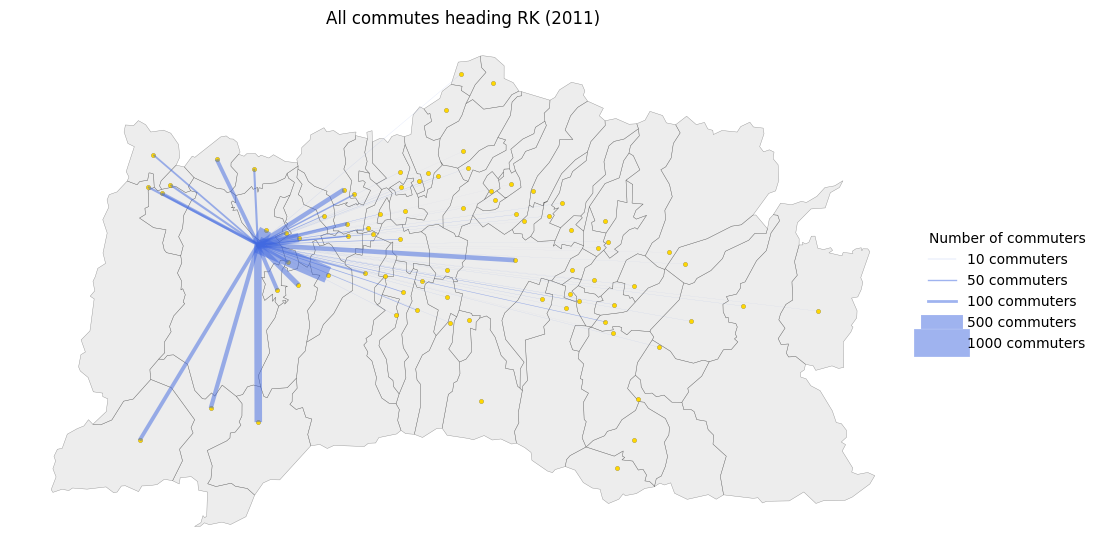

In [39]:
flows_510998 = line_gdf[line_gdf["kod_dest"] == "510998"]
print(flows_510998.sort_values(by = "pocet11", ascending = False))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "royalblue",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510998.plot(
    ax = ax,
    linewidth = flows_510998["pocet11"]/50,
    alpha = 0.5,
    color = "royalblue",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All commutes heading RK (2011)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/RK_flows_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

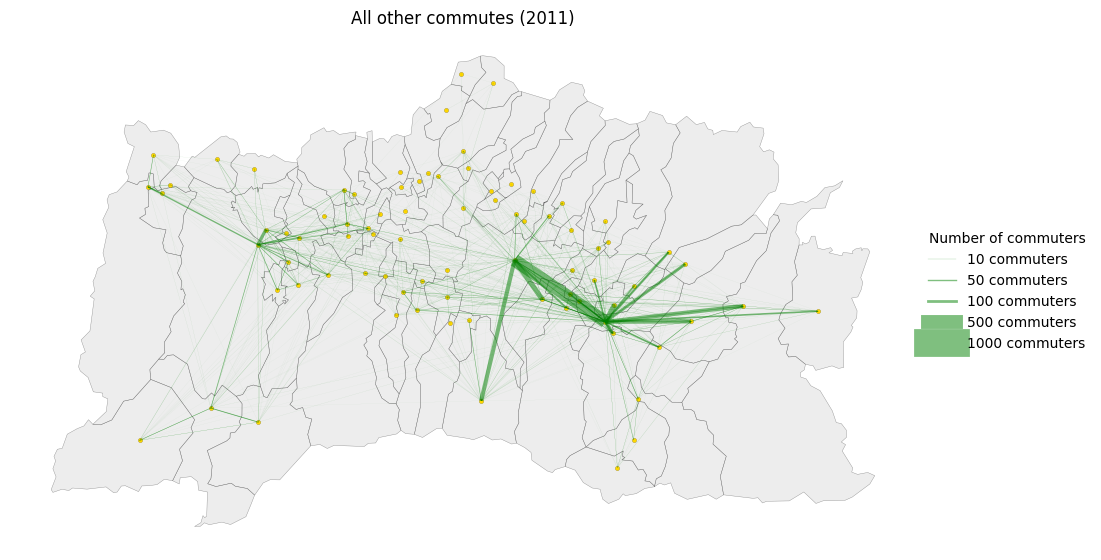

In [40]:
flows_other = line_gdf[(~line_gdf["kod_dest"].isin(["510262", "510998"]))]

lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "green",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_other.plot(
    ax = ax,
    linewidth = flows_other["pocet11"]/50,
    alpha = 0.5,
    color = "green",
    label = "other flows"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All other commutes (2011)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/other_flows_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

   Unnamed: 0   obecA   obecB  pocet  okresA  okresB        obecA_nazov  \
0         1.0  507300  507300   18.0  SK0318  SK0318          Ivachnová   
1        36.0  510262  507300    3.0  SK0315  SK0318  Liptovský Mikuláš   
2       108.0  510301  507300    5.0  SK0318  SK0318           Bešeňová   
3       173.0  510408  507300    1.0  SK0315  SK0318            Dúbrava   
4       205.0  510424  507300    1.0  SK0315  SK0318           Gôtovany   

  obecB_nazov  IDN4_x        obecA_nazov  \
0   Ivachnová  507300          Ivachnová   
1   Ivachnová  510262  Liptovský Mikuláš   
2   Ivachnová  510301           Bešeňová   
3   Ivachnová  510408            Dúbrava   
4   Ivachnová  510424           Gôtovany   

                                          geometry_x  IDN4_y obecB_nazov  \
0  POLYGON Z ((-394781.2 -1189720.44 0, -394660.5...  507300   Ivachnová   
1  MULTIPOLYGON Z (((-384549.42 -1188431.31 0, -3...  507300   Ivachnová   
2  POLYGON Z ((-391918.29 -1186162.77 0, -391612....  50

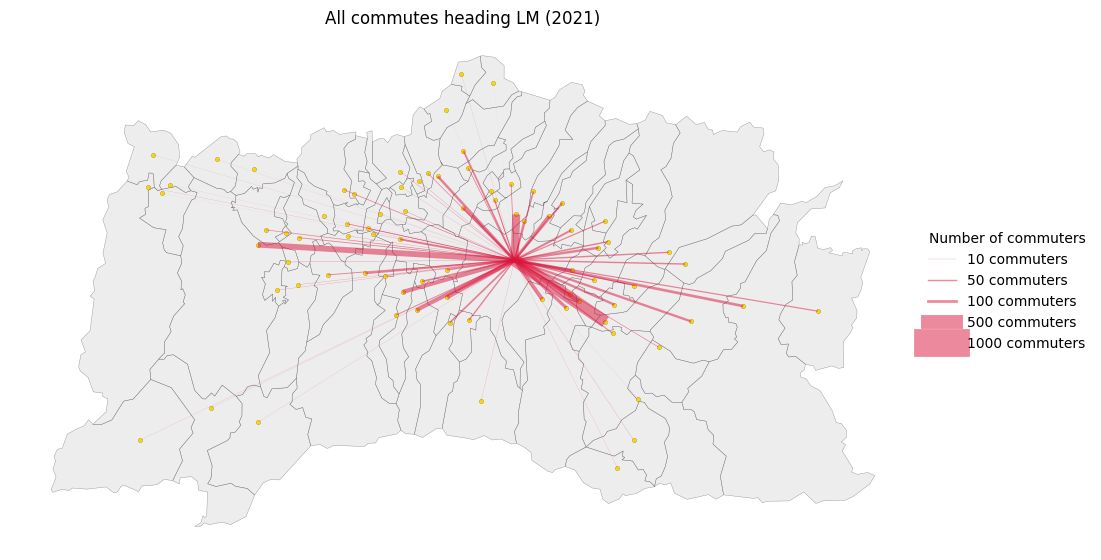

In [41]:
commute21 = commute21.merge(
    map2,
    left_on = "obecA",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecA_nazov"})
commuting21 = commute21.merge(
    map2,
    left_on = "obecB",
    right_on = "IDN4",
    how = "right"
).rename(columns = {"NM4": "obecB_nazov"})
# print(commute1.head())

print(commuting21.head())
commuting21 = commuting21.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecA",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "start_x", "y": "start_y", "kod": "kod_start"})

commuting_21 = commuting21.merge(
    obce_gdf[["kod", "x", "y"]],
    left_on = "obecB",
    right_on = "kod",
    how = "left"
).rename(columns={"x": "end_x", "y": "end_y", "kod": "kod_dest"})
commuting21_gdf = gpd.GeoDataFrame(
    commuting_21,
    geometry=[Point(xy) for xy in zip(commuting_21["start_x"], commuting_21["start_y"])],
    crs="EPSG:5514"
)
# print(commuting_gdf.head())

background = gpd.read_file(r"../data/geo/liptov.shp")

commuting_21["geometry"] = commuting_21.apply(
    lambda row: LineString([(row["start_x"], row["start_y"]), (row["end_x"], row["end_y"])]),
    axis = 1
)
line_gdf = gpd.GeoDataFrame(commuting_21, geometry = "geometry", crs="EPSG:5514")

flows_510262 = line_gdf[line_gdf["kod_dest"] == "510262"]

lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "crimson",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510262.plot(
    ax = ax,
    linewidth = flows_510262["pocet"]/50,
    alpha = 0.5,
    color = "crimson",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)


plt.title("All commutes heading LM (2021)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/LM_flows_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

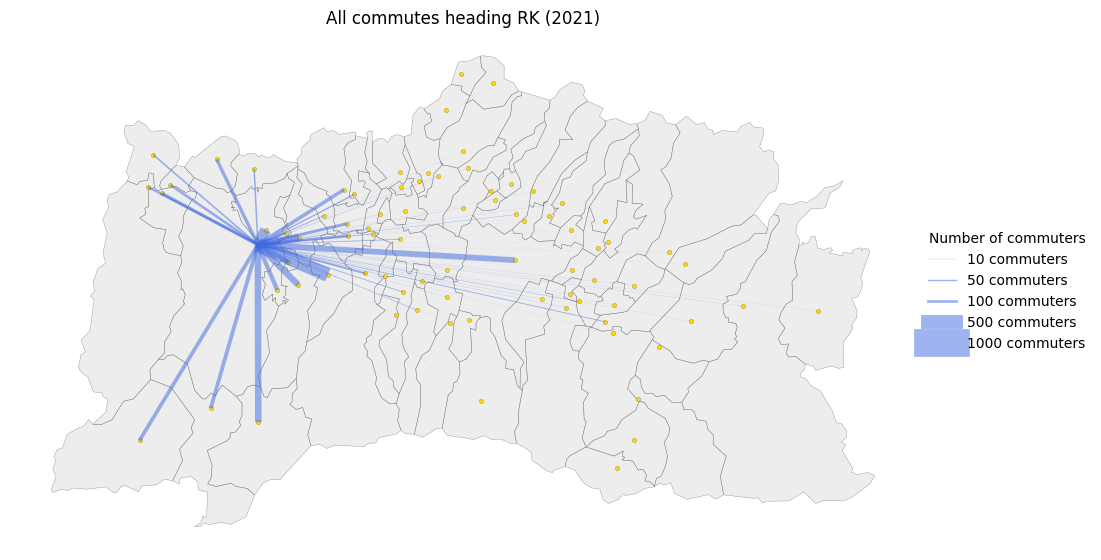

In [42]:
flows_510998 = line_gdf[line_gdf["kod_dest"] == "510998"]
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "royalblue",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_510998.plot(
    ax = ax,
    linewidth = flows_510998["pocet"]/50,
    alpha = 0.5,
    color = "royalblue",
    label = "flows to LM"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All commutes heading RK (2021)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/RK_flows_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

      Unnamed: 0   obecA   obecB  pocet  okresA  okresB        obecA_nazov  \
519        532.0  510726  510726  902.0  SK0315  SK0315   Liptovský Hrádok   
494         59.0  510262  510726  403.0  SK0315  SK0315  Liptovský Mikuláš   
1082        86.0  510262  511196  199.0  SK0315  SK0315  Liptovský Mikuláš   
550       1070.0  511170  510726  156.0  SK0315  SK0315           Východná   
556       1154.0  580287  510726  154.0  SK0315  SK0315    Liptovský Peter   
...          ...     ...     ...    ...     ...     ...                ...   
753        215.0  510424  510904    1.0  SK0315  SK0315           Gôtovany   
446        932.0  511048  510661    1.0  SK0315  SK0318         Svätý Kríž   
751        121.0  510301  510904    1.0  SK0318  SK0315           Bešeňová   
394       1006.0  511111  510611    1.0  SK0315  SK0315          Vavrišovo   
1136         NaN     NaN     NaN    NaN     NaN     NaN                NaN   

              obecB_nazov  IDN4_x        obecA_nazov  ...  IDN4

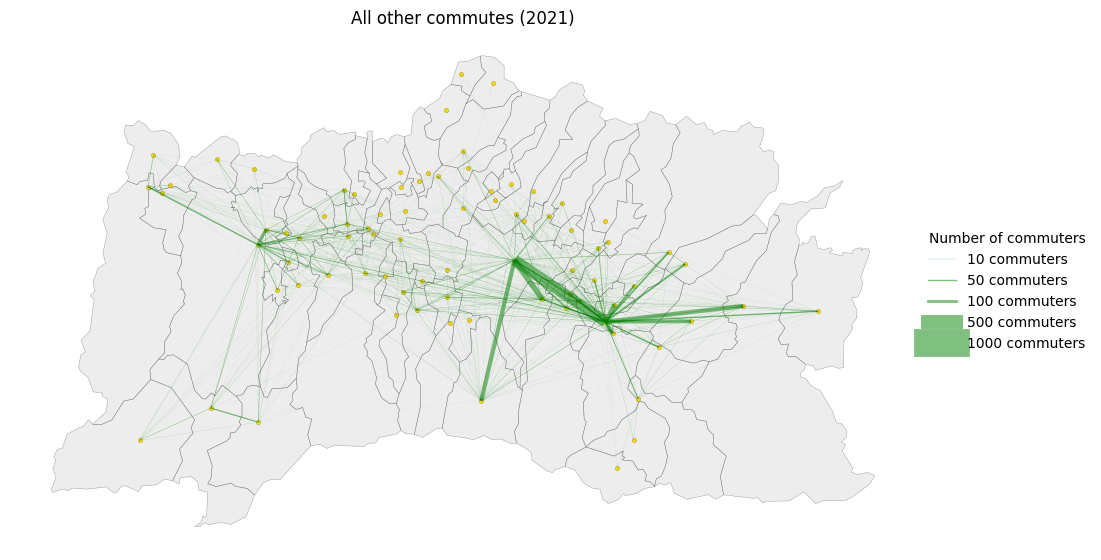

In [44]:
flows_other = line_gdf[(~line_gdf["kod_dest"].isin(["510262", "510998"]))]
print(flows_other.sort_values(by = "pocet", ascending = False))
lines = [
    Line2D(
        [0], [0],
        alpha = 0.5,
        color = "green",
        linewidth = val/scale,
        label = f"{val} commuters"
    )
    for val in flow_values
]
fig, ax = plt.subplots(figsize = (11.69, 8.27))
# plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = ax,
    alpha = 0.4,
    edgecolor = "black",
    color = "lightgray",
    linewidth = 0.3
)
flows_other.plot(
    ax = ax,
    linewidth = flows_other["pocet"].fillna(0)/50,
    alpha = 0.5,
    color = "green",
    label = "other flows"
)
obce_gdf.plot(
    ax = ax,
    color = "gold",
    markersize = 10.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.legend(
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = True
)
flows_legend = ax.legend(
    handles = lines,
    title = "Number of commuters",
    loc = "center left",
    bbox_to_anchor = (1, 0.5),
    frameon = False
)
plt.title("All other commutes (2021)")
plt.axis(False)
plt.grid(False)

plt.savefig("../result_maps/flows/other_flows_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()